In [1]:
# Importing the required python packages

!pip install pandas_datareader # to install pandas_datareader module
!pip install yfinance # to install yfinance module

import pandas as pd   # used for working around data
import numpy as np  # used for numerical/statistical functions
import matplotlib.pyplot as plt  # used for creating charts/graphics
import pandas_datareader.data as web  # used for extracting data from web sources
import yfinance as yf    # used for extracting data from yahoo finance
yf.pdr_override()   # bugfix for conflict between pandas_datareader & yfinance 
from datetime import datetime   # used to convert the date & time format of the data

In [2]:
# User Inputs
start_date = datetime(2022, 1, 1)   # from what date the price data to be downloaded
end_date = datetime(2023, 12, 31)   # till what date the price data to be downloaded

# the ticker symbols of the stocks using which the portfolio needs to be built
stocks = ['HEROMOTOCO.NS', 'OIL.NS', 'PIIND.NS', 'HINDPETRO.NS', 'ZYDUSLIFE.NS']

# create x number of randomly weighted portfolios from which the best need to be chosen
number_of_portfolios = 25000

risk_free = 0.071  ## risk-free rate

In [3]:
# Create an empty table space(dataframe) for storing the return data
returns = pd.DataFrame()

In [4]:
# Create a looping function that :
# 1. Downloads the stock price data for all the ticker symbols defined above
# 2. Compute the percentage change (returns)


for ticker in stocks:
  data = web.get_data_yahoo(ticker, start = start_date, end = end_date)   # download data from yfinance
  data = pd.DataFrame(data)   # store it in a table form(dataframe)
  data[ticker] = data['Adj Close'].pct_change()  # calculating the returns for each day using pct_change()
  if returns.empty:
    returns = data[[ticker]]
  else:
    returns = returns.join(data[[ticker]], how = 'outer') # using outer join
    # adds a new column next to existing data and stores the return data

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


In [5]:
# drop the missing values using dropna()
returns = returns.dropna()

In [6]:
returns.shape # to find the number of rows and columns in the data. There are 492 rows and 5 columns.

(492, 5)

In [7]:
returns.head()   # displays the top 5 rows of a dataframe

,HEROMOTOCO.NS,OIL.NS,PIIND.NS,HINDPETRO.NS,ZYDUSLIFE.NS
Date,,,,,
2022-01-04,0.003351,-0.009306,-0.012403,0.003368,-0.026401
2022-01-05,0.008491,-0.010155,-0.006868,0.055052,-0.012698
2022-01-06,-0.003990,0.014876,-0.012996,-0.000477,-0.003597
2022-01-07,0.001242,0.081880,-0.001777,0.018622,-0.014439
2022-01-10,0.031612,0.004438,-0.020922,0.020469,0.007214


In [8]:
returns.tail()   # displays the bottom 5 rows of a dataframe

,HEROMOTOCO.NS,OIL.NS,PIIND.NS,HINDPETRO.NS,ZYDUSLIFE.NS
Date,,,,,
2023-12-22,0.022220,-0.008237,0.000876,-0.017035,0.012659
2023-12-26,0.033476,0.022639,0.006972,0.040211,-0.005515
2023-12-27,-0.000774,0.001572,0.003172,-0.005987,0.018412
2023-12-28,0.026807,0.001046,0.006353,0.093754,-0.003267
2023-12-29,-0.008075,-0.027567,0.008924,-0.044894,0.004079


In [9]:
# Create variables to compute and store the data
portfolio_weights = []
portfolio_returns = []
portfolio_risks = []
portfolio_sharpe = []

In [10]:
# Computing the weights, returns, risks and sharpe for number of portfolios defined

for portfolio in range(number_of_portfolios):
  weights = np.random.random_sample(len(stocks))  # generated 5 random numbers
  weights = np.round(weights/np.sum(weights),3)   # converts the random numbers into weights
  portfolio_weights.append(weights)   # adds the weights to the array portfolio_weights
  ann_return = np.sum(returns.mean()*weights)*252     # compute the annualised portfolio return as weighted average
  portfolio_returns.append(ann_return)   # add the return to the array portfolio_returns
  covar_matrix = returns.cov()*252   # creates the covariance matrix
  ann_stdev = np.sqrt(np.dot(weights.T, np.dot(covar_matrix, weights)))  # computes the portfolio standard deviation
  portfolio_risks.append(ann_stdev)   # add the standard deviation to the array portfolio_risks
  sharpe = (ann_return - risk_free)/ann_stdev  # computes the sharpe ratio
  portfolio_sharpe.append(sharpe)   # add the sharpe to the array portfolio_sharpe

portfolio_returns = np.array(portfolio_returns)  # store the data in an array form
portfolio_risks = np.array(portfolio_risks)
portfolio_sharpe = np.array(portfolio_sharpe)

portfolio_parameters = [portfolio_returns, portfolio_risks, portfolio_sharpe, portfolio_weights]
portfolio_data = pd.DataFrame(portfolio_parameters).T    # transposing the portfolio_parameters
portfolio_data.columns = ['Return', 'Risk', 'Sharpe', 'Weights'] # renaming the columns in the dataframe
print(portfolio_data)

         Return      Risk    Sharpe                              Weights
0       0.24998  0.171435  1.044011  [0.177, 0.114, 0.234, 0.227, 0.248]
1      0.260678   0.18085  1.048814   [0.269, 0.038, 0.059, 0.223, 0.41]
2       0.28065   0.21009  0.997904    [0.025, 0.394, 0.411, 0.09, 0.08]
3      0.307822  0.182675  1.296416   [0.234, 0.271, 0.119, 0.26, 0.117]
4      0.243411  0.180781    0.9537    [0.187, 0.059, 0.19, 0.304, 0.26]
...         ...       ...       ...                                  ...
24995  0.270301  0.168246  1.184579   [0.21, 0.197, 0.253, 0.085, 0.256]
24996    0.2705  0.173473   1.15004  [0.246, 0.139, 0.174, 0.258, 0.183]
24997  0.230828  0.190926  0.837124  [0.201, 0.002, 0.167, 0.043, 0.587]
24998  0.271822  0.170336  1.178977  [0.143, 0.222, 0.231, 0.115, 0.289]
24999  0.284003  0.195465  1.089727   [0.098, 0.292, 0.251, 0.319, 0.04]

[25000 rows x 4 columns]


In [11]:
# identify the max sharpe ratio portfolio
max_sharpe = portfolio_data.iloc[portfolio_data['Sharpe'].astype(float).idxmax()]
print('Highest Sharpe Portfolio:')
print(max_sharpe)
print(stocks)
print("")

Highest Sharpe Portfolio:
Return                                0.363261
Risk                                  0.198569
Sharpe                                1.471835
Weights    [0.455, 0.361, 0.005, 0.034, 0.144]
Name: 24784, dtype: object
['HEROMOTOCO.NS', 'OIL.NS', 'PIIND.NS', 'HINDPETRO.NS', 'ZYDUSLIFE.NS']



In [12]:
# Thus the maximum sharpe ratio is 1.471835 with the portfolio-weight combination of 
#['HEROMOTOCO.NS'(0.455), 'OIL.NS'(0.361), 'PIIND.NS'(0.005), 'HINDPETRO.NS'(0.034), 'ZYDUSLIFE.NS'(0.144)]

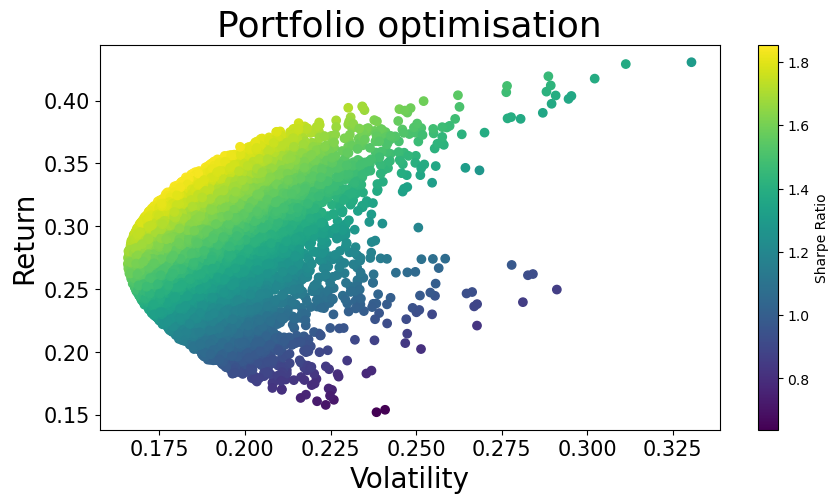

In [13]:
# Visualisation for efficient frontier

plt.figure(figsize = (10,5))
plt.scatter(portfolio_risks, portfolio_returns,
           c = portfolio_returns / portfolio_risks)
plt.title('Portfolio optimisation', fontsize = 26)
plt.xlabel('Volatility', fontsize = 20)
plt.ylabel('Return', fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.colorbar(label = 'Sharpe Ratio')
plt.show()

# The Minimum Variance Portfolio(MVP) is at the peak of the curve (0.165 Volatility, 0.27 Return)
# Efficient frontier are the portfolios on the top of the curve (above the MVP)
# All the portfolios below the MVP are inefficient portfolios

In [14]:
# Additionally these are the min risk and max return portfolios
min_risk = portfolio_data.iloc[portfolio_data['Risk'].astype(float).idxmin()]
max_ret = portfolio_data.iloc[portfolio_data['Return'].astype(float).idxmax()]

print('Lowest Risk Portfolio:')
print(min_risk)
print(stocks)
print('')

print('Highest Return Portfolio:')
print(max_ret)
print(stocks)
print('')

Lowest Risk Portfolio:
Return                                0.270179
Risk                                    0.1658
Sharpe                                 1.20132
Weights    [0.258, 0.158, 0.213, 0.106, 0.264]
Name: 5002, dtype: object
['HEROMOTOCO.NS', 'OIL.NS', 'PIIND.NS', 'HINDPETRO.NS', 'ZYDUSLIFE.NS']

Highest Return Portfolio:
Return                              0.430563
Risk                                0.330428
Sharpe                              1.088174
Weights    [0.0, 0.842, 0.025, 0.089, 0.044]
Name: 6150, dtype: object
['HEROMOTOCO.NS', 'OIL.NS', 'PIIND.NS', 'HINDPETRO.NS', 'ZYDUSLIFE.NS']

